
 MOTION BLUR ENHANCEMENT

Sharpening Method      : Unsharp Masking
Gaussian Kernel        : (5, 5)
Sharpen Strength (α)   : 1.5
Canny Thresholds       : 100 - 200
Blur Threshold Factor  : 0.75

 FRAME ANALYSIS TABLE 

Frame                Before     After      Improve      Edge_B       Edge_A       Status    
-----------------------------------------------------------------------------------------------
AlligatorCracking_frame_0.jpg 140.59     140.59     0            44140        44140        SHARP     
AlligatorCracking_frame_20.jpg 77.81      77.81      0            24850        24850        SHARP     
AlligatorCracking_frame_35.jpg 68.02      68.02      0            20792        20792        SHARP     
AlligatorCracking_frame_4.jpg 107.25     107.25     0            34448        34448        SHARP     
AlligatorCracking_frame_51.jpg 68.63      68.63      0            20513        20513        SHARP     
AlligatorCracking_frame_9.jpg 86.03      86.03      0            27786        2

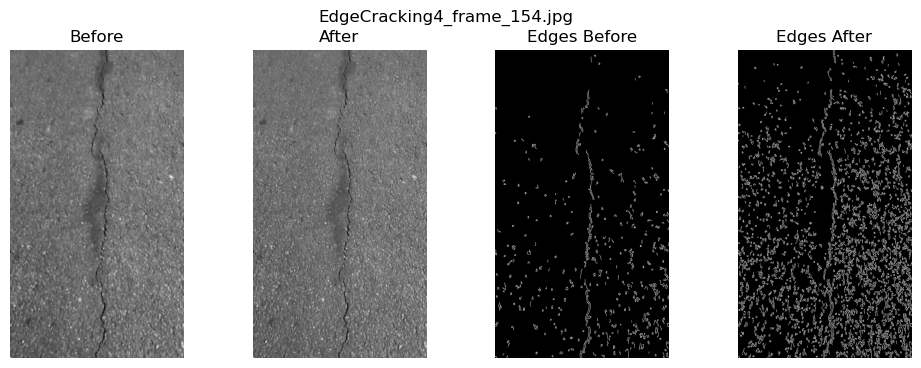

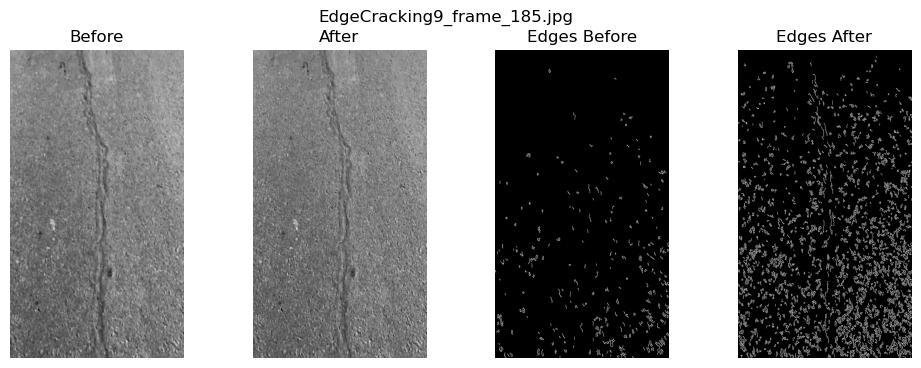

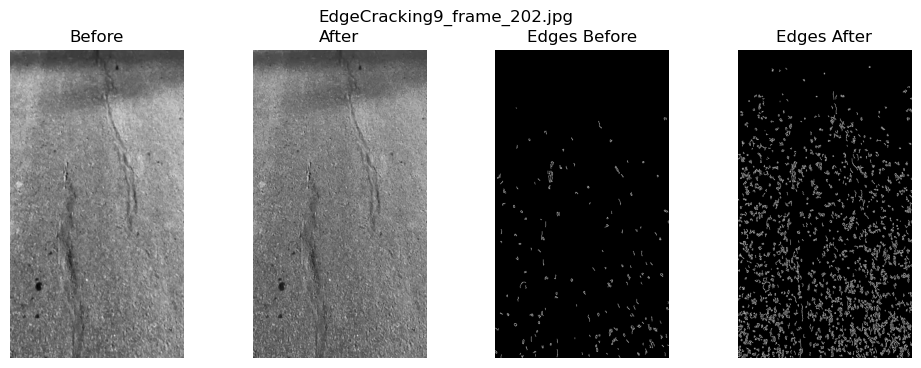

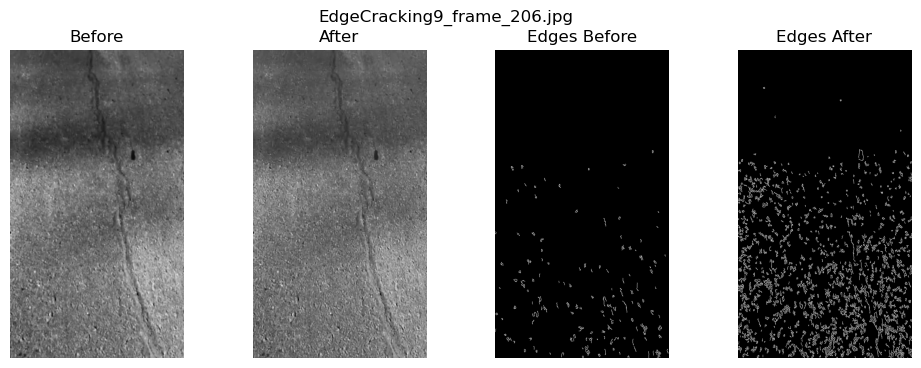

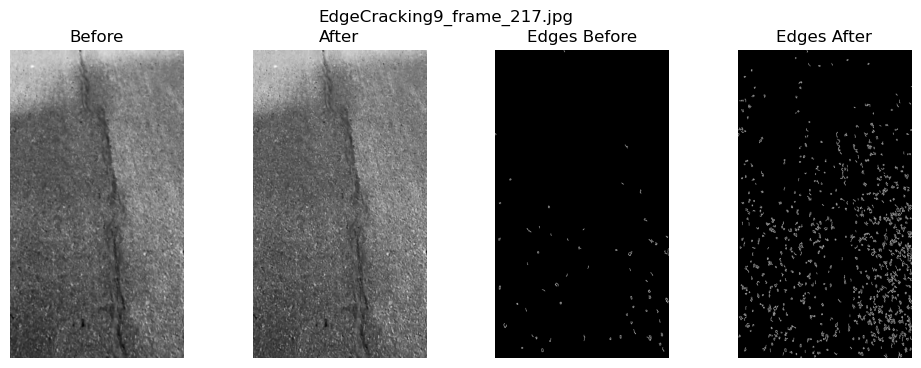

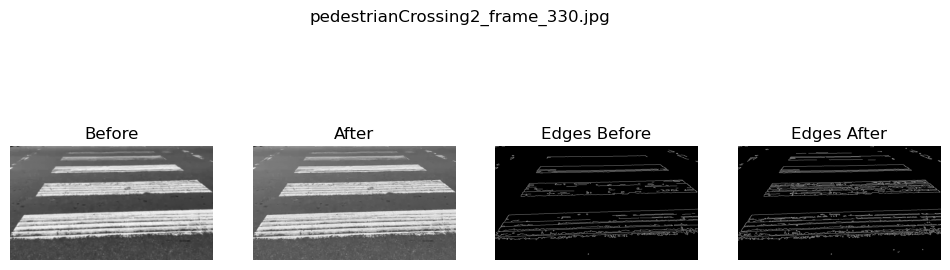

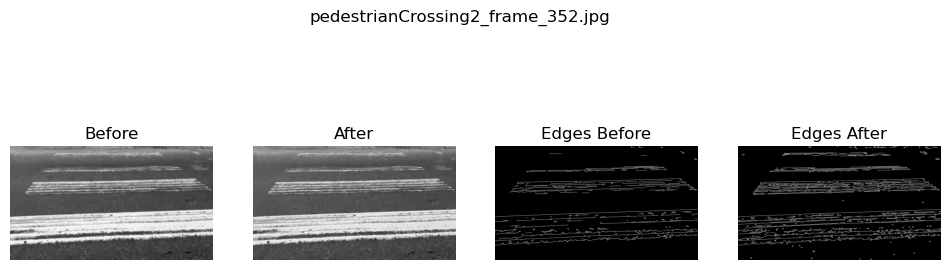

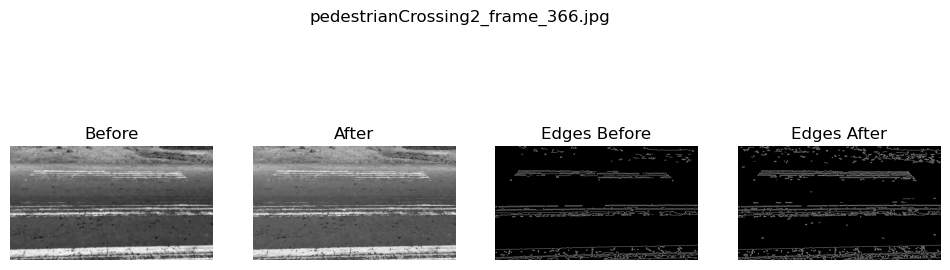

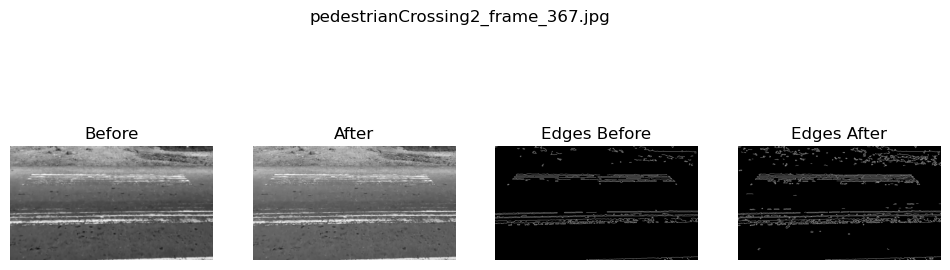

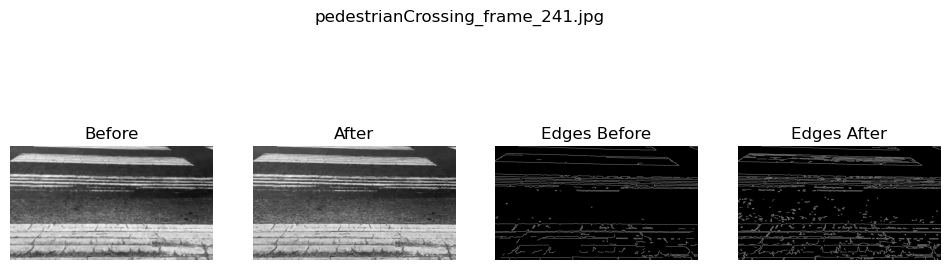


Unsharp Masking Enhancement Completed Successfully.


In [8]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

GAUSSIAN_KERNEL = (5,5)
SHARPEN_STRENGTH = 1.5
CANNY_LOW = 100
CANNY_HIGH = 200
BLUR_THRESHOLD_FACTOR = 0.75

print("\n MOTION BLUR ENHANCEMENT\n")
print("Sharpening Method      : Unsharp Masking")
print("Gaussian Kernel        :", GAUSSIAN_KERNEL)
print("Sharpen Strength (α)   :", SHARPEN_STRENGTH)
print("Canny Thresholds       :", CANNY_LOW, "-", CANNY_HIGH)
print("Blur Threshold Factor  :", BLUR_THRESHOLD_FACTOR)

input_folder = "fr"
frame_files = sorted(os.listdir(input_folder))

sharpness_values = []
valid_frames = []

for file in frame_files:

    if not file.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    path = os.path.join(input_folder, file)
    image = cv2.imread(path)

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    sharpness_values.append(lap_var)
    valid_frames.append((file, gray, lap_var))

mean_sharpness = np.mean(sharpness_values)
threshold = BLUR_THRESHOLD_FACTOR * mean_sharpness

analysis_results = []

for file, gray, lap_var in valid_frames:

    edges_before = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)
    edge_before_count = np.count_nonzero(edges_before)

    if lap_var < threshold:

        # --------- Unsharp Masking ----------
        blurred = cv2.GaussianBlur(gray, GAUSSIAN_KERNEL, 0)
        sharpened = cv2.addWeighted(gray, 1 + SHARPEN_STRENGTH,
                                    blurred, -SHARPEN_STRENGTH, 0)

        sharp_after = cv2.Laplacian(sharpened, cv2.CV_64F).var()

        edges_after = cv2.Canny(sharpened, CANNY_LOW, CANNY_HIGH)
        edge_after_count = np.count_nonzero(edges_after)

        improvement = sharp_after - lap_var
        status = "BLURRED"

    else:
        sharpened = gray
        sharp_after = lap_var
        edge_after_count = edge_before_count
        improvement = 0
        status = "SHARP"

    analysis_results.append([
        file,
        round(lap_var,2),
        round(sharp_after,2),
        round(improvement,2),
        edge_before_count,
        edge_after_count,
        status,
        gray,
        sharpened
    ])


print("\n FRAME ANALYSIS TABLE \n")
print("{:<20} {:<10} {:<10} {:<12} {:<12} {:<12} {:<10}".format(
    "Frame","Before","After","Improve","Edge_B","Edge_A","Status"
))
print("-"*95)

for row in analysis_results:
    print("{:<20} {:<10} {:<10} {:<12} {:<12} {:<12} {:<10}".format(
        row[0], row[1], row[2], row[3], row[4], row[5], row[6]
    ))

blur_count = sum(1 for r in analysis_results if r[6] == "BLURRED")
sharp_count = sum(1 for r in analysis_results if r[6] == "SHARP")
improvements = [r[3] for r in analysis_results if r[6] == "BLURRED"]

print("\n FINAL SUMMARY \n")
print("Total Frames Checked :", len(analysis_results))
print("Blurred Frames       :", blur_count)
print("Sharp Frames         :", sharp_count)
print("Mean Sharpness       :", round(mean_sharpness,2))
print("Blur Threshold       :", round(threshold,2))

if improvements:
    print("Average Improvement  :", round(np.mean(improvements),2))
    print("Maximum Improvement  :", round(np.max(improvements),2))
    print("Minimum Improvement  :", round(np.min(improvements),2))
else:
    print("No blurred frames detected.")


print("\nDisplaying First 10 Blurred Frame Comparisons...\n")

display_limit = 10
counter = 0

for row in analysis_results:

    if row[6] == "BLURRED" and counter < display_limit:

        gray = row[7]
        sharpened = row[8]

        edges_before = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)
        edges_after = cv2.Canny(sharpened, CANNY_LOW, CANNY_HIGH)

        plt.figure(figsize=(12,4))

        plt.subplot(1,4,1)
        plt.imshow(gray, cmap='gray')
        plt.title("Before")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(sharpened, cmap='gray')
        plt.title("After")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(edges_before, cmap='gray')
        plt.title("Edges Before")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(edges_after, cmap='gray')
        plt.title("Edges After")
        plt.axis("off")

        plt.suptitle(row[0])
        plt.show()

        counter += 1

print("\nUnsharp Masking Enhancement Completed Successfully.")